In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import mne
from scipy.signal import welch
from specparam import SpectralModel
from specparam.utils.download import load_example_data
from specparam.metrics.definitions import check_metrics
import pandas as pd
import warnings

from neurodsp.sim import sim_synaptic_current
from neurodsp.utils import create_times
from neurodsp.filt import filter_signal
from neurodsp.spectral import compute_spectrum

warnings.filterwarnings('ignore')

In [19]:
# flanker

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 399119  =      0.000 ...   798.238 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
410 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 410 events and 401 original time points ...
0 bad epochs dropped
P3b (Congruent):   -0.000 µV
P3b (Incongruent): -0.000 µV
Delta P3b (Incong - Cong): 0.000 µV


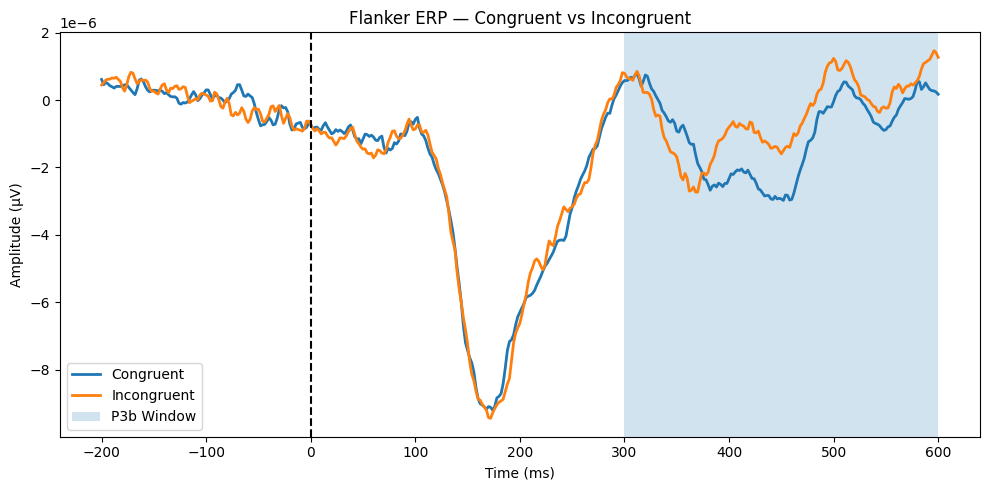

In [20]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-flanker_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

congruent_keys = ['11', '12']
incongruent_keys = ['21', '22']

congruent_event_id = {
    k: event_id_clean[k] for k in congruent_keys if k in event_id_clean
}

incongruent_event_id = {
    k: event_id_clean[k] for k in incongruent_keys if k in event_id_clean
}

stim_keys = congruent_keys + incongruent_keys
stim_event_id = {k: event_id_clean[k] for k in stim_keys if k in event_id_clean}
stim_event_values = list(stim_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=stim_event_id,
    tmin=-0.2,
    tmax=0.6,
    baseline=(-0.2, 0),
    preload=True
)

epochs = epochs.pick(['Pz'])

times = epochs.times * 1000

epochs_congruent = epochs[congruent_keys]
epochs_incongruent = epochs[incongruent_keys]

data_cong = epochs_congruent.get_data()[:, 0, :]
data_incong = epochs_incongruent.get_data()[:, 0, :]

erp_cong = data_cong.mean(axis=0)
erp_incong = data_incong.mean(axis=0)

p3b_mask = (times >= 300) & (times <= 600)

p3b_cong = data_cong[:, p3b_mask].mean(axis=1).mean()
p3b_incong = data_incong[:, p3b_mask].mean(axis=1).mean()

delta_p3b = p3b_incong - p3b_cong

print(f"P3b (Congruent):   {p3b_cong:.3f} µV")
print(f"P3b (Incongruent): {p3b_incong:.3f} µV")
print(f"Delta P3b (Incong - Cong): {delta_p3b:.3f} µV")

plt.figure(figsize=(10, 5))

plt.plot(times, erp_cong, label='Congruent', linewidth=2)
plt.plot(times, erp_incong, label='Incongruent', linewidth=2)

plt.axvline(0, linestyle='--', color='black')
plt.axvspan(300, 600, alpha=0.2, label='P3b Window')

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title("Flanker ERP — Congruent vs Incongruent")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# visual search

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-visualsearch_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 330679  =      0.000 ...   661.358 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S201'), np.str_('Stimulus/S202'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
330 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 330 events and 401 original time points ...
0 bad epochs dropped
P3b (Stimulus-locked): 0.000 µV


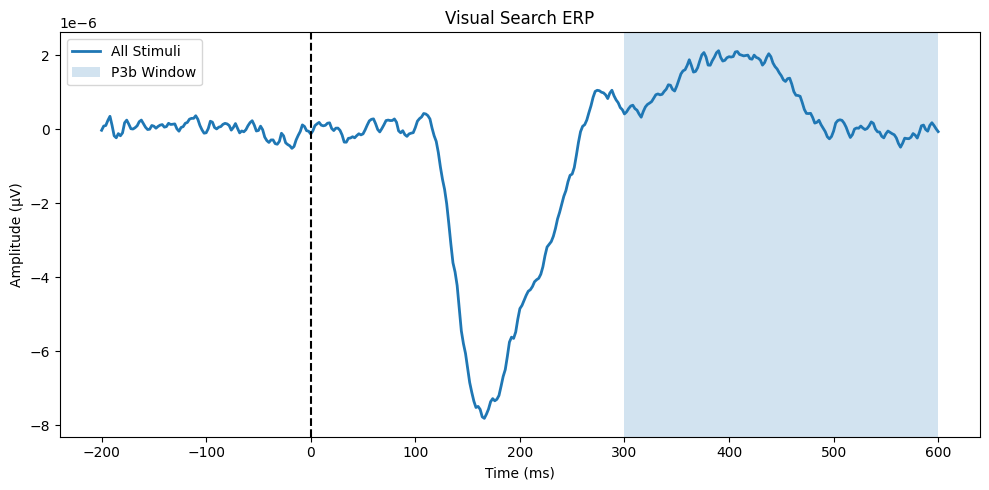

In [22]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-visualsearch_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

stim_keys = ['111','112','121','122','211','212','221','222']

stim_event_id = {
    k: event_id_clean[k] for k in stim_keys if k in event_id_clean
}

stim_event_values = list(stim_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=stim_event_id,
    tmin=-0.2,
    tmax=0.6,
    baseline=(-0.2, 0),
    preload=True
)

epochs = epochs.pick(['Pz'])
times = epochs.times * 1000

data = epochs.get_data()[:, 0, :]
erp = data.mean(axis=0)

p3b_mask = (times >= 300) & (times <= 600)

p3b = data[:, p3b_mask].mean(axis=1).mean()

print(f"P3b (Stimulus-locked): {p3b:.3f} µV")

plt.figure(figsize=(10, 5))

plt.plot(times, erp, label='All Stimuli', linewidth=2)

plt.axvline(0, linestyle='--', color='black')
plt.axvspan(300, 600, alpha=0.2, label='P3b Window')

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title("Visual Search ERP")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
#correct vs incorrect

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-visualsearch_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 330679  =      0.000 ...   661.358 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S201'), np.str_('Stimulus/S202'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
348 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 348 events and 401 original time points ...
0 bad epochs dropped
P3b (Correct):   -0.000 µV
P3b (Incorrect): 0.000 µV
Delta P3b (Incorrect - Correct): 0.000 µV


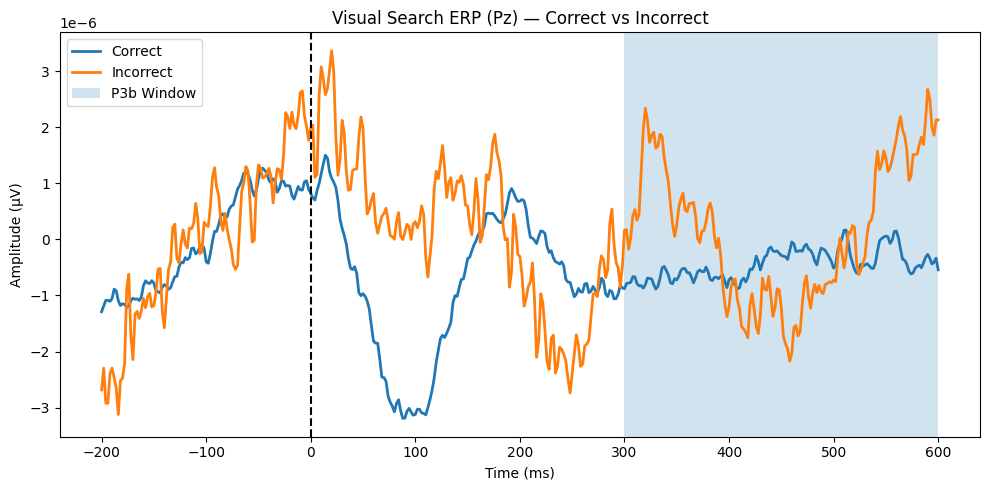

In [24]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-visualsearch_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

correct_keys = ['201']
incorrect_keys = ['202']

correct_event_id = {
    k: event_id_clean[k] for k in correct_keys if k in event_id_clean
}

incorrect_event_id = {
    k: event_id_clean[k] for k in incorrect_keys if k in event_id_clean
}

stim_keys = correct_keys + incorrect_keys
stim_event_id = {k: event_id_clean[k] for k in stim_keys if k in event_id_clean}
stim_event_values = list(stim_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=stim_event_id,
    tmin=-0.2,
    tmax=0.6,
    baseline=(-0.2, 0),
    preload=True
)

epochs = epochs.pick(['Pz'])
times = epochs.times * 1000

epochs_correct = epochs[correct_keys]
epochs_incorrect = epochs[incorrect_keys]

data_correct = epochs_correct.get_data()[:, 0, :]
data_incorrect = epochs_incorrect.get_data()[:, 0, :]

erp_correct = data_correct.mean(axis=0)
erp_incorrect = data_incorrect.mean(axis=0)

p3b_mask = (times >= 300) & (times <= 600)

p3b_correct = data_correct[:, p3b_mask].mean(axis=1).mean()
p3b_incorrect = data_incorrect[:, p3b_mask].mean(axis=1).mean()

delta_p3b = p3b_incorrect - p3b_correct

print(f"P3b (Correct):   {p3b_correct:.3f} µV")
print(f"P3b (Incorrect): {p3b_incorrect:.3f} µV")
print(f"Delta P3b (Incorrect - Correct): {delta_p3b:.3f} µV")

plt.figure(figsize=(10, 5))

plt.plot(times, erp_correct, label='Correct', linewidth=2)
plt.plot(times, erp_incorrect, label='Incorrect', linewidth=2)

plt.axvline(0, linestyle='--', color='black')
plt.axvspan(300, 600, alpha=0.2, label='P3b Window')

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title("Visual Search ERP (Pz) — Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# pre-stimulus (-500ms-0ms) aperiodic for flanker incongruent

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 399119  =      0.000 ...   798.238 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
204 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 204 events and 551 original time points ...
0 bad epochs dropped
Mean Pre-Stim Exponent: 1.232
Mean Pre-Stim Offset:   -11.811


<Figure size 800x500 with 0 Axes>

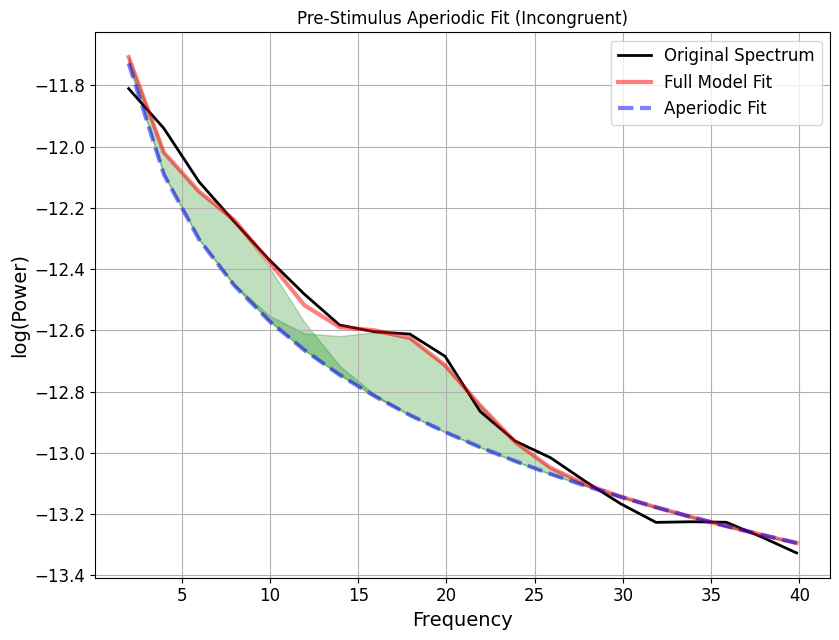

In [26]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-flanker_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

stim_keys = ['21', '22']
#stim_keys = ['11', '12', '21', '22']
stim_event_id = {k: event_id_clean[k] for k in stim_keys if k in event_id_clean}

stim_event_values = list(stim_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=stim_event_id,
    tmin = -0.5,
    tmax=0.6,
    baseline=None,
    preload=True
)

epochs = epochs.pick(['Pz'])

data = epochs.get_data()[:, 0, :]
times = epochs.times * 1000

pre_mask = (times >= -500) & (times <= 0)

slopes = []
offsets = []
all_psds = []

for trial in data:
    pre_data = trial[pre_mask]

    freqs, psd = welch(
        pre_data,
        fs=fs,
        nperseg=len(pre_data)
    )

    freq_mask = (freqs >= 1) & (freqs <= 40)
    freqs = freqs[freq_mask]
    psd = psd[freq_mask]

    all_psds.append(psd)

    fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
    fm.fit(freqs, psd)

    exp = fm.get_params('aperiodic', 'exponent')
    off = fm.get_params('aperiodic', 'offset')

    slopes.append(exp)
    offsets.append(off)

exp_pre = np.mean(slopes)
off_pre = np.mean(offsets)
print(f"Mean Pre-Stim Exponent: {np.mean(slopes):.3f}")
print(f"Mean Pre-Stim Offset:   {np.mean(offsets):.3f}")

mean_psd = np.mean(all_psds, axis=0)

fm_mean = SpectralModel(aperiodic_mode='fixed', verbose=False)
fm_mean.fit(freqs, mean_psd)

plt.figure(figsize=(8, 5))
fm_mean.plot(plot_peaks='shade')
plt.title("Pre-Stimulus Aperiodic Fit (Incongruent)")
plt.show()

In [27]:
# post stimulus (300-600ms) aperiodic for flanker incongruent

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 399119  =      0.000 ...   798.238 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
204 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 204 events and 551 original time points ...
0 bad epochs dropped
Post-Stim Exponent (Incongruent): 1.872
Post-Stim Offset   (Incongruent): -10.060


<Figure size 800x500 with 0 Axes>

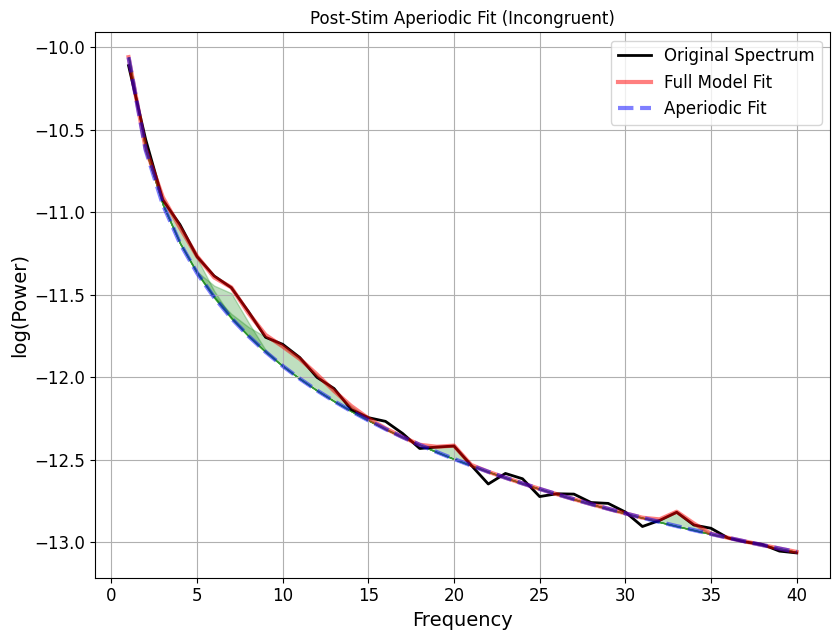

In [28]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-flanker_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

incongruent_keys = ['21', '22']
incong_event_id = {
    k: event_id_clean[k] for k in incongruent_keys if k in event_id_clean
}

stim_event_values = list(incong_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=incong_event_id,
    tmin=-0.5,
    tmax=0.6,
    baseline=None,
    preload=True
)

epochs = epochs.pick(['Pz'])

data = epochs.get_data()[:, 0, :]
times = epochs.times * 1000

post_mask = (times >= 300) & (times <= 600)

all_post = data[:, post_mask].flatten()

freqs, psd = welch(
    all_post,
    fs=fs,
    nperseg=int(1 * fs)
)

freq_mask = (freqs >= 1) & (freqs <= 40)
freqs = freqs[freq_mask]
psd = psd[freq_mask]

fm = SpectralModel(
    aperiodic_mode='fixed',
    peak_width_limits=[1, 8],
    verbose=False
)

fm.fit(freqs, psd)

exp_post = fm.get_params('aperiodic', 'exponent')
off_post = fm.get_params('aperiodic', 'offset')

print(f"Post-Stim Exponent (Incongruent): {exp_post:.3f}")
print(f"Post-Stim Offset   (Incongruent): {off_post:.3f}")

plt.figure(figsize=(8, 5))
fm.plot(plot_peaks='shade')
plt.title("Post-Stim Aperiodic Fit (Incongruent)")
plt.show()

In [29]:
delta_slope_incongruent = exp_post - exp_pre
delta_slope_incongruent

np.float64(0.6400759280499702)

In [30]:
# pre-stimulus (-500ms-0ms) aperiodic for flanker congruent

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 399119  =      0.000 ...   798.238 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
206 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 206 events and 551 original time points ...
0 bad epochs dropped
Mean Pre-Stim Exponent: 1.307
Mean Pre-Stim Offset:   -11.754


<Figure size 800x500 with 0 Axes>

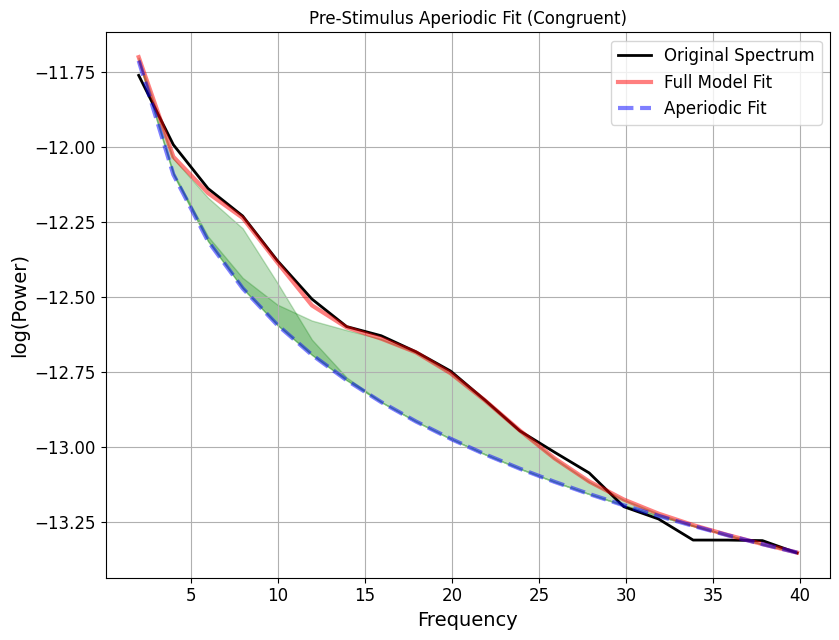

In [31]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-flanker_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

stim_keys = ['11', '12']
#stim_keys = ['11', '12', '21', '22']
stim_event_id = {k: event_id_clean[k] for k in stim_keys if k in event_id_clean}

stim_event_values = list(stim_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=stim_event_id,
    tmin = -0.5,
    tmax=0.6,
    baseline=None,
    preload=True
)

epochs = epochs.pick(['Pz'])

data = epochs.get_data()[:, 0, :]
times = epochs.times * 1000

pre_mask = (times >= -500) & (times <= 0)

slopes = []
offsets = []
all_psds = []

for trial in data:
    pre_data = trial[pre_mask]

    freqs, psd = welch(
        pre_data,
        fs=fs,
        nperseg=len(pre_data)
    )

    freq_mask = (freqs >= 1) & (freqs <= 40)
    freqs = freqs[freq_mask]
    psd = psd[freq_mask]

    all_psds.append(psd)

    fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
    fm.fit(freqs, psd)

    exp = fm.get_params('aperiodic', 'exponent')
    off = fm.get_params('aperiodic', 'offset')

    slopes.append(exp)
    offsets.append(off)

exp_pre = np.mean(slopes)
off_pre = np.mean(offsets)
print(f"Mean Pre-Stim Exponent: {np.mean(slopes):.3f}")
print(f"Mean Pre-Stim Offset:   {np.mean(offsets):.3f}")

mean_psd = np.mean(all_psds, axis=0)

fm_mean = SpectralModel(aperiodic_mode='fixed', verbose=False)
fm_mean.fit(freqs, mean_psd)

plt.figure(figsize=(8, 5))
fm_mean.plot(plot_peaks='shade')
plt.title("Pre-Stimulus Aperiodic Fit (Congruent)")
plt.show()

In [37]:
# post stimulus (300-600ms) aperiodic for flanker congruent

Extracting parameters from /Users/KeanuVentura/Desktop/SES_Data/sub-007_task-flanker_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 399119  =      0.000 ...   798.238 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 12'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S111'), np.str_('Stimulus/S112'), np.str_('Stimulus/S121'), np.str_('Stimulus/S122'), np.str_('Stimulus/S211'), np.str_('Stimulus/S212'), np.str_('Stimulus/S221'), np.str_('Stimulus/S222')]
Not setting metadata
206 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 206 events and 551 original time points ...
0 bad epochs dropped
Post-Stim Exponent (Congruent): 1.831
Post-Stim Offset   (Congruent): -10.141


<Figure size 800x500 with 0 Axes>

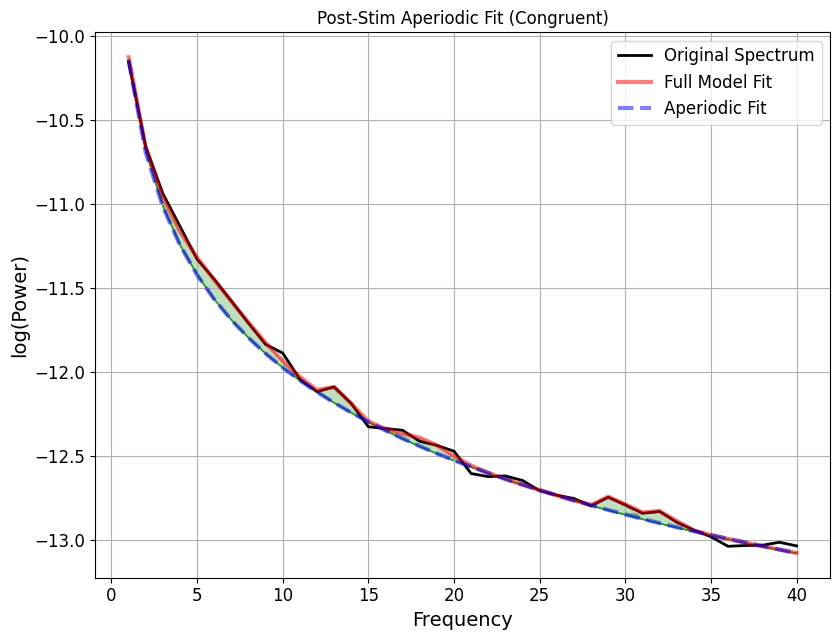

In [35]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/SES_Data')
file_path = DATA_DIR / "sub-007_task-flanker_eeg.vhdr"

raw = mne.io.read_raw_brainvision(file_path, preload=True)
raw.pick_types(eeg=True)

fs = raw.info['sfreq']

events, event_id = mne.events_from_annotations(raw)

event_id_clean = {
    k.split('/')[-1].replace("S", "").strip(): v
    for k, v in event_id.items()
}

congruent_keys = ['11', '12']
cong_event_id = {
    k: event_id_clean[k] for k in congruent_keys if k in event_id_clean
}

stim_event_values = list(cong_event_id.values())
stim_events = events[np.isin(events[:, 2], stim_event_values)]

events_corrected = stim_events.copy()
events_corrected[:, 0] += int(0.02 * fs)

epochs = mne.Epochs(
    raw,
    events_corrected,
    event_id=cong_event_id,
    tmin=-0.5,
    tmax=0.6,
    baseline=None,
    preload=True
)

epochs = epochs.pick(['Pz'])

data = epochs.get_data()[:, 0, :]
times = epochs.times * 1000

post_mask = (times >= 300) & (times <= 600)

all_post = data[:, post_mask].flatten()

freqs, psd = welch(
    all_post,
    fs=fs,
    nperseg=int(1 * fs)
)

freq_mask = (freqs >= 1) & (freqs <= 40)
freqs = freqs[freq_mask]
psd = psd[freq_mask]

fm = SpectralModel(
    aperiodic_mode='fixed',
    peak_width_limits=[1, 8],
    verbose=False
)

fm.fit(freqs, psd)

exp_post = fm.get_params('aperiodic', 'exponent')
off_post = fm.get_params('aperiodic', 'offset')

print(f"Post-Stim Exponent (Congruent): {exp_post:.3f}")
print(f"Post-Stim Offset   (Congruent): {off_post:.3f}")

plt.figure(figsize=(8, 5))
fm.plot(plot_peaks='shade')
plt.title("Post-Stim Aperiodic Fit (Congruent)")
plt.show()

In [34]:
delta_slope_congruent = exp_post - exp_pre
delta_slope_congruent

np.float64(0.523983231013013)

In [38]:
# for both incongruent and congruent slope becomes steeper after stimulus. may be a result of higher cognitive demand. 

In [43]:
delta_diff = delta_slope_incongruent -  delta_slope_congruent
delta_diff

np.float64(0.11609269703695713)

In [41]:
# delta_diff tells how much the brain’s baseline activity adjusts specifically for harder tasks

In [39]:
# delta_diff ≈ +0.12 -> the slope increases more during incongruent trials than congruent trials. 

In [40]:
# suggests that the brain shifts more in its aperiodic state when cognitive control demand is higher

In [ ]:
# can look across SES to see if some groups show less sensitivity to cognitive demand